---
## 1. Setup & Import Libraries

In [48]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
import warnings
import re
from difflib import SequenceMatcher

# Optional: For tokenization analysis
try:
    from transformers import AutoTokenizer
    HAS_TRANSFORMERS = True
except ImportError:
    HAS_TRANSFORMERS = False
    print("⚠️ transformers not installed. Token analysis will be skipped.")

warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
## 2. Load Data

### DPO Format Validation:
- Required fields: `prompt`, `chosen`, `rejected`
- All fields must be non-empty strings
- `chosen` và `rejected` phải khác nhau

In [49]:
# Path configuration
DATA_PATH = Path("../data/dpo.jsonl")

def load_dpo_data(filepath: Path) -> tuple[list[dict], list[dict]]:
    """
    Load DPO data from JSONL file with validation.
    
    Returns:
        - data: List of valid DPO entries
        - invalid_entries: List of invalid entries with reasons
    """
    data = []
    invalid_entries = []
    required_fields = ['prompt', 'chosen', 'rejected']
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f, 1):
            try:
                entry = json.loads(line.strip())
                
                # Check required fields
                missing_fields = [f for f in required_fields if f not in entry]
                if missing_fields:
                    invalid_entries.append({
                        'line': idx, 
                        'reason': f'Missing fields: {missing_fields}'
                    })
                    continue
                
                # Check non-empty
                empty_fields = [f for f in required_fields if not entry[f].strip()]
                if empty_fields:
                    invalid_entries.append({
                        'line': idx,
                        'reason': f'Empty fields: {empty_fields}'
                    })
                    continue
                
                # Check chosen != rejected
                if entry['chosen'].strip() == entry['rejected'].strip():
                    invalid_entries.append({
                        'line': idx,
                        'reason': 'Chosen and rejected are identical'
                    })
                    continue
                
                data.append(entry)
                
            except json.JSONDecodeError as e:
                invalid_entries.append({'line': idx, 'reason': f'JSON error: {e}'})
    
    return data, invalid_entries

# Load data
dpo_data, invalid_entries = load_dpo_data(DATA_PATH)

print(f"📁 Data loaded from: {DATA_PATH}")
print(f"✅ Valid entries: {len(dpo_data):,}")
print(f"❌ Invalid entries: {len(invalid_entries)}")

if invalid_entries:
    print(f"\n⚠️ Sample invalid entries:")
    for entry in invalid_entries[:5]:
        print(f"   Line {entry['line']}: {entry['reason']}")

📁 Data loaded from: ../data/dpo.jsonl
✅ Valid entries: 3,722
❌ Invalid entries: 1

⚠️ Sample invalid entries:
   Line 3653: JSON error: Expecting value: line 1 column 1 (char 0)


In [50]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame(dpo_data)

# Add length columns
df['prompt_len'] = df['prompt'].str.len()
df['chosen_len'] = df['chosen'].str.len()
df['rejected_len'] = df['rejected'].str.len()
df['len_diff'] = df['chosen_len'] - df['rejected_len']
df['len_ratio'] = df['chosen_len'] / df['rejected_len'].replace(0, 1)

print(f"\n📊 Dataset Shape: {df.shape}")
df.head()


📊 Dataset Shape: (3722, 8)


,prompt,chosen,rejected,prompt_len,chosen_len,rejected_len,len_diff,len_ratio
0,Làm sao để nhận biết bệnh xơ cứng rải rác ở gi...,"Ở giai đoạn đầu, xơ cứng rải rác có thể biểu h...",Xơ cứng rải rác thường khó nhận biết ở giai đo...,58,425,205,220,2.073171
1,Điều trị bệnh xơ cứng rải rác bằng phương pháp...,Phương pháp truyền tế bào gốc tạo máu tự thân ...,Truyền tế bào gốc tự thân là cách chữa xơ cứng...,93,475,173,302,2.745665
2,Vitamin C có vai trò gì trong cơ thể?,Vitamin C là một chất chống oxy hóa quan trọng...,Vitamin C chỉ giúp cơ thể chống cảm lạnh và là...,37,363,129,234,2.813953
3,Liệu vitamin C có thể giúp giảm thiểu các triệ...,Nghiên cứu cho thấy vitamin C không ngăn ngừa ...,Vitamin C có thể ngay lập tức chữa cảm lạnh và...,67,391,108,283,3.620370
4,Nên uống vitamin C vào thời điểm nào trong ngà...,Vitamin C tan trong nước và cơ thể không tích ...,Bạn có thể uống vitamin C bất cứ lúc nào trong...,75,320,134,186,2.388060


---
## 3. Basic Statistics

### Key Metrics for DPO:
- Length distribution của prompt, chosen, rejected
- Length difference between chosen and rejected
- Ratio analysis

In [51]:
# Basic statistics
stats_df = df[['prompt_len', 'chosen_len', 'rejected_len', 'len_diff', 'len_ratio']].describe()

print("📏 Length Statistics (in characters):")
print(stats_df.round(2).to_string())

# Word counts
df['prompt_words'] = df['prompt'].str.split().str.len()
df['chosen_words'] = df['chosen'].str.split().str.len()
df['rejected_words'] = df['rejected'].str.split().str.len()

print("\n📝 Word Count Statistics:")
word_stats = df[['prompt_words', 'chosen_words', 'rejected_words']].describe()
print(word_stats.round(2).to_string())

📏 Length Statistics (in characters):
       prompt_len  chosen_len  rejected_len  len_diff  len_ratio
count     3722.00     3722.00       3722.00   3722.00    3722.00
mean        69.79      378.83        252.53    126.29       1.92
std         37.14      171.74        183.75    140.64       0.83
min         12.00      109.00         38.00  -1165.00       0.23
25%         48.00      258.00        113.00     81.00       1.27
50%         61.00      345.00        170.00    139.00       1.90
75%         79.00      446.00        367.00    194.75       2.45
max        332.00     2088.00       1637.00   1497.00       7.38

📝 Word Count Statistics:
       prompt_words  chosen_words  rejected_words
count       3722.00       3722.00         3722.00
mean          15.59         81.33           56.07
std            7.94         35.41           40.54
min            3.00         24.00            9.00
25%           11.00         56.00           25.00
50%           14.00         75.00           38.00
75

In [52]:
# Summary table
summary = pd.DataFrame({
    'Metric': [
        'Total Samples',
        'Avg Prompt Length (chars)',
        'Avg Chosen Length (chars)',
        'Avg Rejected Length (chars)',
        'Avg Length Difference (chosen - rejected)',
        'Chosen longer than Rejected (%)',
        'Rejected longer than Chosen (%)',
        'Similar length (diff < 50 chars) (%)'
    ],
    'Value': [
        len(df),
        f"{df['prompt_len'].mean():.1f}",
        f"{df['chosen_len'].mean():.1f}",
        f"{df['rejected_len'].mean():.1f}",
        f"{df['len_diff'].mean():.1f}",
        f"{100 * (df['len_diff'] > 0).mean():.1f}%",
        f"{100 * (df['len_diff'] < 0).mean():.1f}%",
        f"{100 * (df['len_diff'].abs() < 50).mean():.1f}%"
    ]
})

print("📊 DPO Dataset Summary:")
print(summary.to_string(index=False))

📊 DPO Dataset Summary:
                                   Metric Value
                            Total Samples  3722
                Avg Prompt Length (chars)  69.8
                Avg Chosen Length (chars) 378.8
              Avg Rejected Length (chars) 252.5
Avg Length Difference (chosen - rejected) 126.3
          Chosen longer than Rejected (%) 88.1%
          Rejected longer than Chosen (%) 11.8%
     Similar length (diff < 50 chars) (%)  7.9%


---
## 4. Length Distribution Analysis

### Quan trọng cho DPO:
- **Length bias**: Nếu chosen luôn dài hơn rejected, model có thể học "dài = tốt"
- **Best practice**: Nên có sự đa dạng về độ dài
- **Ideal**: Preference dựa trên quality, không phải length

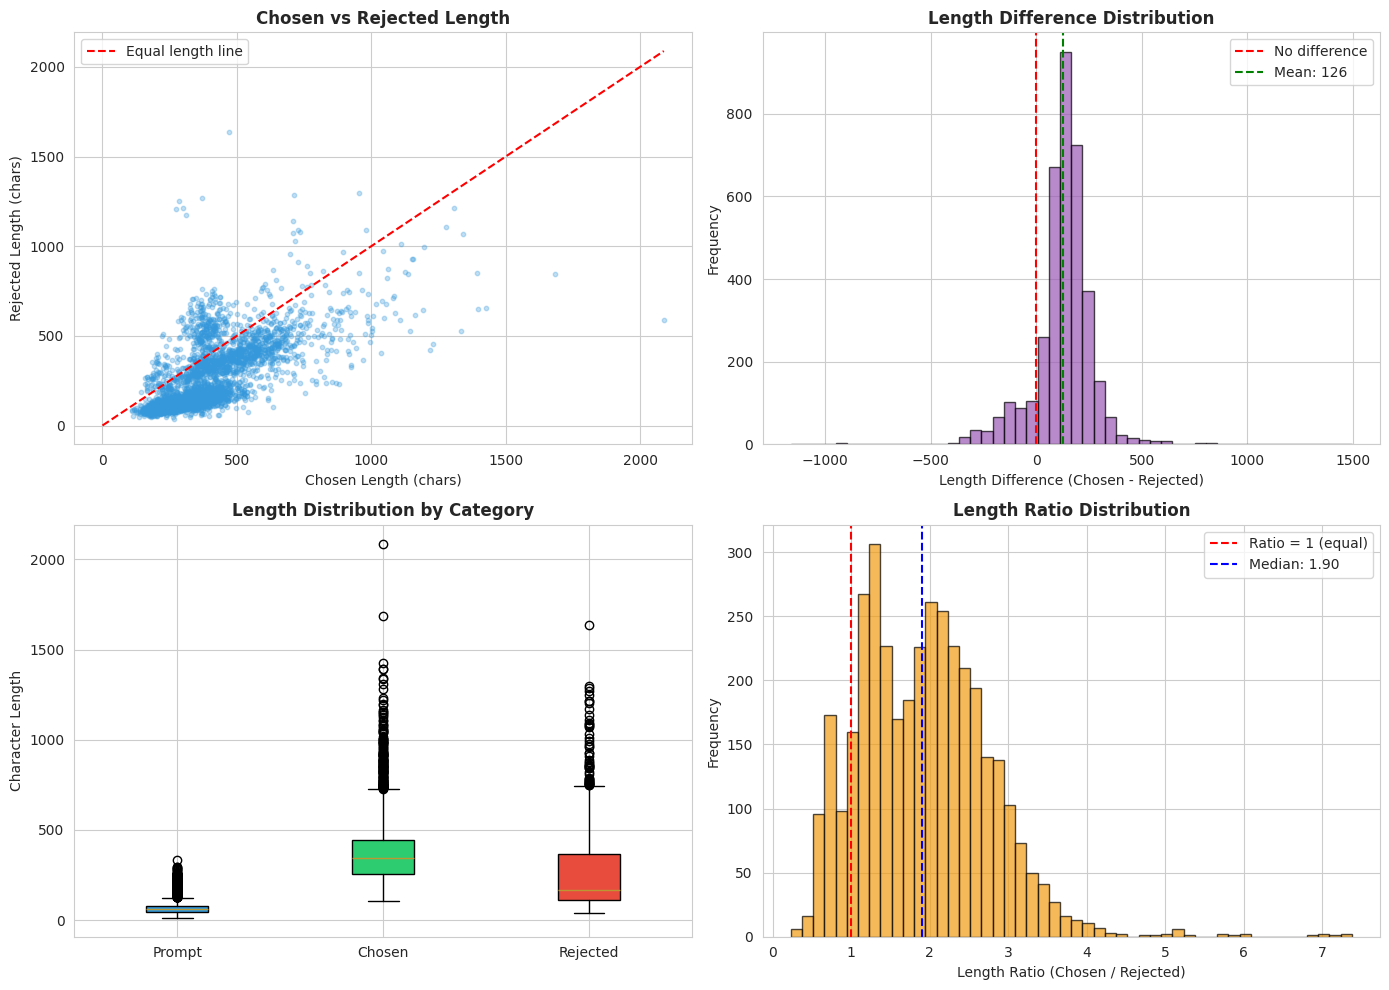


📊 Length Bias Analysis:
   Chosen longer in 88.1% of cases
   Rejected longer in 11.8% of cases
   Average length ratio (chosen/rejected): 1.92

⚠️ WARNING: Significant length bias detected! Chosen responses are consistently longer.
   This may cause the model to learn 'longer = better' instead of quality signals.


In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Chosen vs Rejected length comparison
ax1 = axes[0, 0]
ax1.scatter(df['chosen_len'], df['rejected_len'], alpha=0.3, s=10, c='#3498DB')
max_len = max(df['chosen_len'].max(), df['rejected_len'].max())
ax1.plot([0, max_len], [0, max_len], 'r--', label='Equal length line')
ax1.set_xlabel('Chosen Length (chars)')
ax1.set_ylabel('Rejected Length (chars)')
ax1.set_title('Chosen vs Rejected Length', fontweight='bold')
ax1.legend()

# 2. Length difference distribution
ax2 = axes[0, 1]
ax2.hist(df['len_diff'], bins=50, color='#9B59B6', edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--', label='No difference')
ax2.axvline(df['len_diff'].mean(), color='green', linestyle='--', label=f"Mean: {df['len_diff'].mean():.0f}")
ax2.set_xlabel('Length Difference (Chosen - Rejected)')
ax2.set_ylabel('Frequency')
ax2.set_title('Length Difference Distribution', fontweight='bold')
ax2.legend()

# 3. Box plot comparison
ax3 = axes[1, 0]
box_data = [df['prompt_len'], df['chosen_len'], df['rejected_len']]
bp = ax3.boxplot(box_data, labels=['Prompt', 'Chosen', 'Rejected'], patch_artist=True)
colors = ['#3498DB', '#2ECC71', '#E74C3C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax3.set_ylabel('Character Length')
ax3.set_title('Length Distribution by Category', fontweight='bold')

# 4. Length ratio distribution
ax4 = axes[1, 1]
# Clip extreme ratios for visualization
clipped_ratio = df['len_ratio'].clip(0.1, 10)
ax4.hist(clipped_ratio, bins=50, color='#F39C12', edgecolor='black', alpha=0.7)
ax4.axvline(1, color='red', linestyle='--', label='Ratio = 1 (equal)')
ax4.axvline(clipped_ratio.median(), color='blue', linestyle='--', label=f"Median: {clipped_ratio.median():.2f}")
ax4.set_xlabel('Length Ratio (Chosen / Rejected)')
ax4.set_ylabel('Frequency')
ax4.set_title('Length Ratio Distribution', fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.show()

# Analysis insights
print("\n📊 Length Bias Analysis:")
print(f"   Chosen longer in {100*(df['len_diff'] > 0).mean():.1f}% of cases")
print(f"   Rejected longer in {100*(df['len_diff'] < 0).mean():.1f}% of cases")
print(f"   Average length ratio (chosen/rejected): {df['len_ratio'].mean():.2f}")

if df['len_diff'].mean() > 100:
    print("\n⚠️ WARNING: Significant length bias detected! Chosen responses are consistently longer.")
    print("   This may cause the model to learn 'longer = better' instead of quality signals.")

---
## 5. Token Analysis

### Mục đích:
- Đếm tokens cho DPO training
- Xác định max_length phù hợp
- Kiểm tra token budget cho prompt + chosen + rejected

In [54]:
if HAS_TRANSFORMERS:
    MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
    
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
        print(f"✅ Loaded tokenizer: {MODEL_NAME}")
        
        # Token analysis
        token_data = {
            'prompt_tokens': [],
            'chosen_tokens': [],
            'rejected_tokens': [],
            'total_tokens': []  # prompt + max(chosen, rejected)
        }
        
        for _, row in df.iterrows():
            prompt_tok = len(tokenizer.encode(row['prompt']))
            chosen_tok = len(tokenizer.encode(row['chosen']))
            rejected_tok = len(tokenizer.encode(row['rejected']))
            
            token_data['prompt_tokens'].append(prompt_tok)
            token_data['chosen_tokens'].append(chosen_tok)
            token_data['rejected_tokens'].append(rejected_tok)
            token_data['total_tokens'].append(prompt_tok + max(chosen_tok, rejected_tok))
        
        # Add to dataframe
        for key, values in token_data.items():
            df[key] = values
        
        # Statistics
        print(f"\n📊 Token Statistics:")
        print(f"   Prompt tokens - Mean: {np.mean(token_data['prompt_tokens']):.1f}, Max: {max(token_data['prompt_tokens'])}")
        print(f"   Chosen tokens - Mean: {np.mean(token_data['chosen_tokens']):.1f}, Max: {max(token_data['chosen_tokens'])}")
        print(f"   Rejected tokens - Mean: {np.mean(token_data['rejected_tokens']):.1f}, Max: {max(token_data['rejected_tokens'])}")
        print(f"   Total tokens - Mean: {np.mean(token_data['total_tokens']):.1f}, Max: {max(token_data['total_tokens'])}")
        print(f"   95th percentile total: {np.percentile(token_data['total_tokens'], 95):.0f}")
        print(f"   99th percentile total: {np.percentile(token_data['total_tokens'], 99):.0f}")
        
        HAS_TOKEN_DATA = True
        
    except Exception as e:
        print(f"❌ Failed to load tokenizer: {e}")
        HAS_TOKEN_DATA = False
else:
    print("⏭️ Skipping token analysis")
    HAS_TOKEN_DATA = False

✅ Loaded tokenizer: Qwen/Qwen2.5-1.5B-Instruct

📊 Token Statistics:
   Prompt tokens - Mean: 20.3, Max: 99
   Chosen tokens - Mean: 111.2, Max: 665
   Rejected tokens - Mean: 71.4, Max: 486
   Total tokens - Mean: 136.0, Max: 679
   95th percentile total: 240
   99th percentile total: 349


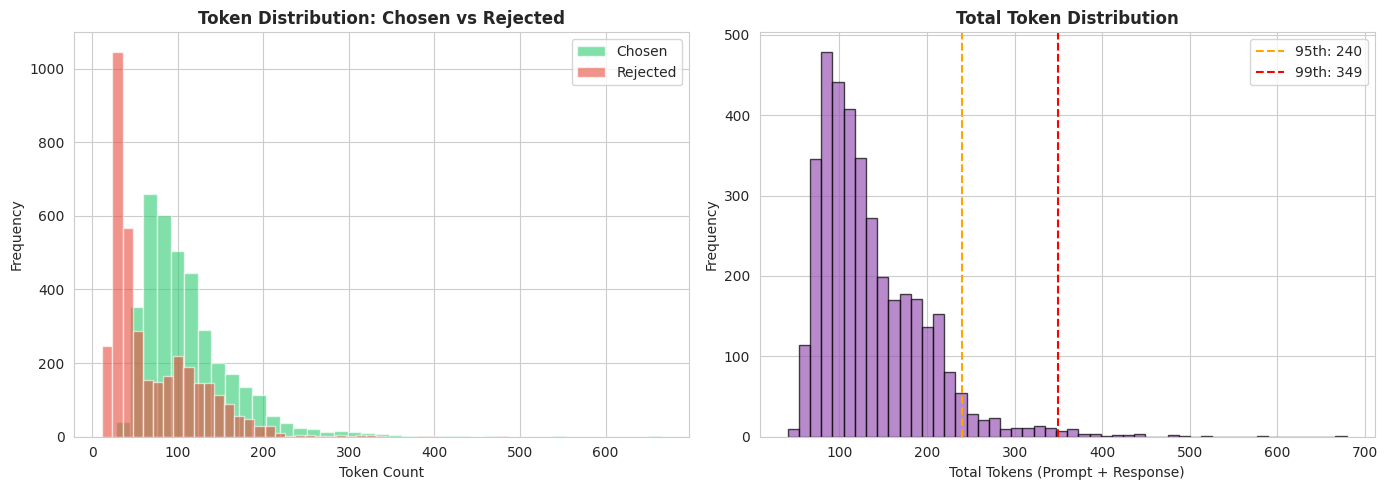


💡 Recommended max_length for DPO: 349


In [55]:
if HAS_TOKEN_DATA:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Token distribution
    ax1 = axes[0]
    ax1.hist(df['chosen_tokens'], bins=40, alpha=0.6, label='Chosen', color='#2ECC71')
    ax1.hist(df['rejected_tokens'], bins=40, alpha=0.6, label='Rejected', color='#E74C3C')
    ax1.set_xlabel('Token Count')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Token Distribution: Chosen vs Rejected', fontweight='bold')
    ax1.legend()
    
    # Total tokens
    ax2 = axes[1]
    ax2.hist(df['total_tokens'], bins=50, color='#9B59B6', edgecolor='black', alpha=0.7)
    ax2.axvline(np.percentile(df['total_tokens'], 95), color='orange', linestyle='--', 
                label=f"95th: {np.percentile(df['total_tokens'], 95):.0f}")
    ax2.axvline(np.percentile(df['total_tokens'], 99), color='red', linestyle='--',
                label=f"99th: {np.percentile(df['total_tokens'], 99):.0f}")
    ax2.set_xlabel('Total Tokens (Prompt + Response)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Total Token Distribution', fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    recommended_max = int(np.percentile(df['total_tokens'], 99))
    print(f"\n💡 Recommended max_length for DPO: {recommended_max}")

---
## 6. Similarity Analysis

### Phân tích sự khác biệt giữa chosen và rejected:
- **Text similarity**: Mức độ giống nhau về nội dung
- **Semantic difference**: Sự khác biệt về ý nghĩa

### Best Practices:
- Chosen và rejected quá giống nhau → weak preference signal
- Chosen và rejected quá khác nhau → có thể không cùng trả lời prompt

In [56]:
def calculate_similarity(text1: str, text2: str) -> float:
    """
    Calculate text similarity using SequenceMatcher.
    Returns value between 0 (completely different) and 1 (identical).
    """
    return SequenceMatcher(None, text1, text2).ratio()

# Calculate similarity for all pairs
print("🔍 Calculating similarity between chosen and rejected...")
df['similarity'] = df.apply(
    lambda row: calculate_similarity(row['chosen'], row['rejected']), 
    axis=1
)

print("\n📊 Similarity Statistics:")
print(f"   Mean similarity: {df['similarity'].mean():.3f}")
print(f"   Median similarity: {df['similarity'].median():.3f}")
print(f"   Min similarity: {df['similarity'].min():.3f}")
print(f"   Max similarity: {df['similarity'].max():.3f}")

# Categorize
very_similar = (df['similarity'] > 0.8).sum()
similar = ((df['similarity'] > 0.5) & (df['similarity'] <= 0.8)).sum()
different = ((df['similarity'] > 0.2) & (df['similarity'] <= 0.5)).sum()
very_different = (df['similarity'] <= 0.2).sum()

print(f"\n📈 Similarity Categories:")
print(f"   Very similar (>0.8): {very_similar} ({100*very_similar/len(df):.1f}%)")
print(f"   Similar (0.5-0.8): {similar} ({100*similar/len(df):.1f}%)")
print(f"   Different (0.2-0.5): {different} ({100*different/len(df):.1f}%)")
print(f"   Very different (<0.2): {very_different} ({100*very_different/len(df):.1f}%)")

if very_similar > len(df) * 0.1:
    print(f"\n⚠️ WARNING: {100*very_similar/len(df):.1f}% of pairs are very similar!")
    print("   This may result in weak preference signals for DPO.")

🔍 Calculating similarity between chosen and rejected...

📊 Similarity Statistics:
   Mean similarity: 0.230
   Median similarity: 0.236
   Min similarity: 0.007
   Max similarity: 0.698

📈 Similarity Categories:
   Very similar (>0.8): 0 (0.0%)
   Similar (0.5-0.8): 43 (1.2%)
   Different (0.2-0.5): 2056 (55.2%)
   Very different (<0.2): 1623 (43.6%)


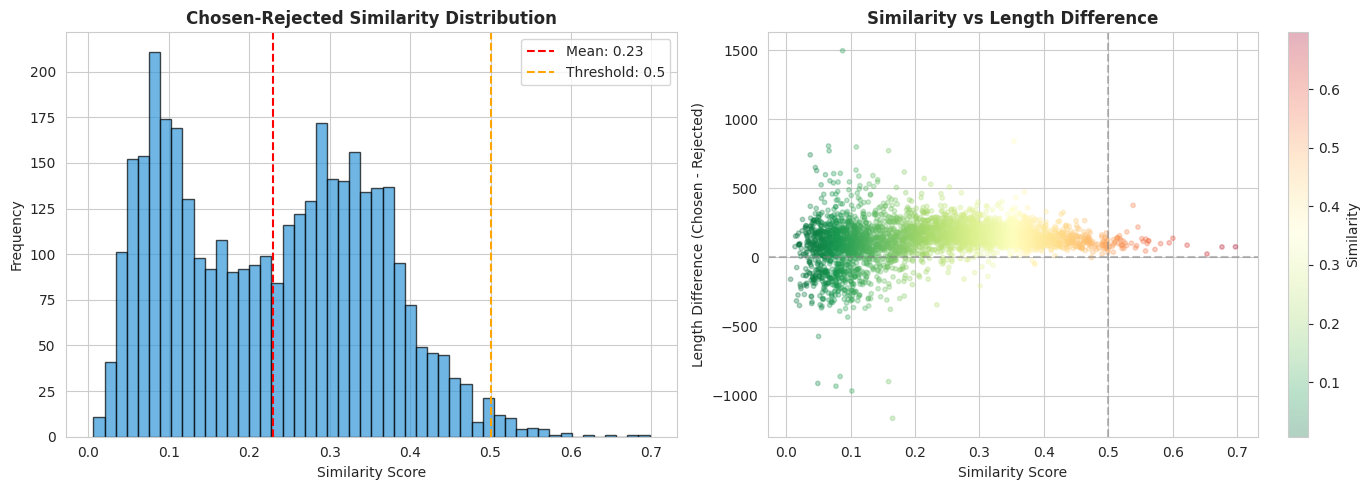

In [57]:
# Visualize similarity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(df['similarity'], bins=50, color='#3498DB', edgecolor='black', alpha=0.7)
ax1.axvline(df['similarity'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df['similarity'].mean():.2f}")
ax1.axvline(0.5, color='orange', linestyle='--', label='Threshold: 0.5')
ax1.set_xlabel('Similarity Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Chosen-Rejected Similarity Distribution', fontweight='bold')
ax1.legend()

# Similarity vs Length Difference
ax2 = axes[1]
scatter = ax2.scatter(df['similarity'], df['len_diff'], alpha=0.3, s=10, c=df['similarity'], cmap='RdYlGn_r')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Similarity Score')
ax2.set_ylabel('Length Difference (Chosen - Rejected)')
ax2.set_title('Similarity vs Length Difference', fontweight='bold')
plt.colorbar(scatter, ax=ax2, label='Similarity')

plt.tight_layout()
plt.show()

---
## 7. Quality Analysis: Chosen vs Rejected

### Phân tích đặc điểm chất lượng:
- Structural elements (lists, paragraphs)
- Medical terminology presence
- Recommendation patterns

In [79]:
def analyze_response_quality(text: str) -> dict:
    """
    Analyze quality indicators in a response.
    """
    return {
        'has_bullet_points': bool(re.search(r'[-•*]\s', text)),
        'has_numbered_list': bool(re.search(r'\d+[.):]\s', text)),
        'has_paragraphs': text.count('\n\n') > 0,
        'sentence_count': len(re.findall(r'[.!?]', text)),
        'has_medical_terms': bool(re.search(
            r'(triệu chứng|chẩn đoán|điều trị|thuốc|bệnh|viêm|nhiễm|xét nghiệm|bác sĩ|chuyên khoa)', 
            text.lower()
        )),
        'has_recommendation': bool(re.search(
            r'(nên|khuyên|cần|phải|đề nghị|khuyến cáo|tốt nhất)', 
            text.lower()
        )),
        'has_disclaimer': bool(re.search(
            r'(bác sĩ|cơ sở y tế|thăm khám|tư vấn|không thay thế|khám|chẩn đoán|bệnh viện|lành mạnh)', 
            text.lower()
        ))
    }

# Analyze both chosen and rejected
chosen_quality = df['chosen'].apply(analyze_response_quality)
rejected_quality = df['rejected'].apply(analyze_response_quality)

# Aggregate
quality_comparison = pd.DataFrame({
    'Quality Indicator': [
        'Has bullet points',
        'Has numbered list', 
        'Has paragraphs',
        'Has medical terms',
        'Has recommendation',
        'Has disclaimer'
    ],
    'Chosen (%)': [
        100 * sum(q['has_bullet_points'] for q in chosen_quality) / len(df),
        100 * sum(q['has_numbered_list'] for q in chosen_quality) / len(df),
        100 * sum(q['has_paragraphs'] for q in chosen_quality) / len(df),
        100 * sum(q['has_medical_terms'] for q in chosen_quality) / len(df),
        100 * sum(q['has_recommendation'] for q in chosen_quality) / len(df),
        100 * sum(q['has_disclaimer'] for q in chosen_quality) / len(df),
    ],
    'Rejected (%)': [
        100 * sum(q['has_bullet_points'] for q in rejected_quality) / len(df),
        100 * sum(q['has_numbered_list'] for q in rejected_quality) / len(df),
        100 * sum(q['has_paragraphs'] for q in rejected_quality) / len(df),
        100 * sum(q['has_medical_terms'] for q in rejected_quality) / len(df),
        100 * sum(q['has_recommendation'] for q in rejected_quality) / len(df),
        100 * sum(q['has_disclaimer'] for q in rejected_quality) / len(df),
    ]
})

quality_comparison['Difference'] = quality_comparison['Chosen (%)'] - quality_comparison['Rejected (%)']

print("📊 Quality Comparison: Chosen vs Rejected")
print(quality_comparison.round(1).to_string(index=False))

📊 Quality Comparison: Chosen vs Rejected
 Quality Indicator  Chosen (%)  Rejected (%)  Difference
 Has bullet points        26.9           6.3        20.7
 Has numbered list        11.8           1.7        10.1
    Has paragraphs        10.7           2.5         8.2
 Has medical terms        83.4          66.7        16.7
Has recommendation        46.8          70.6       -23.8
    Has disclaimer        41.8          21.0        20.8


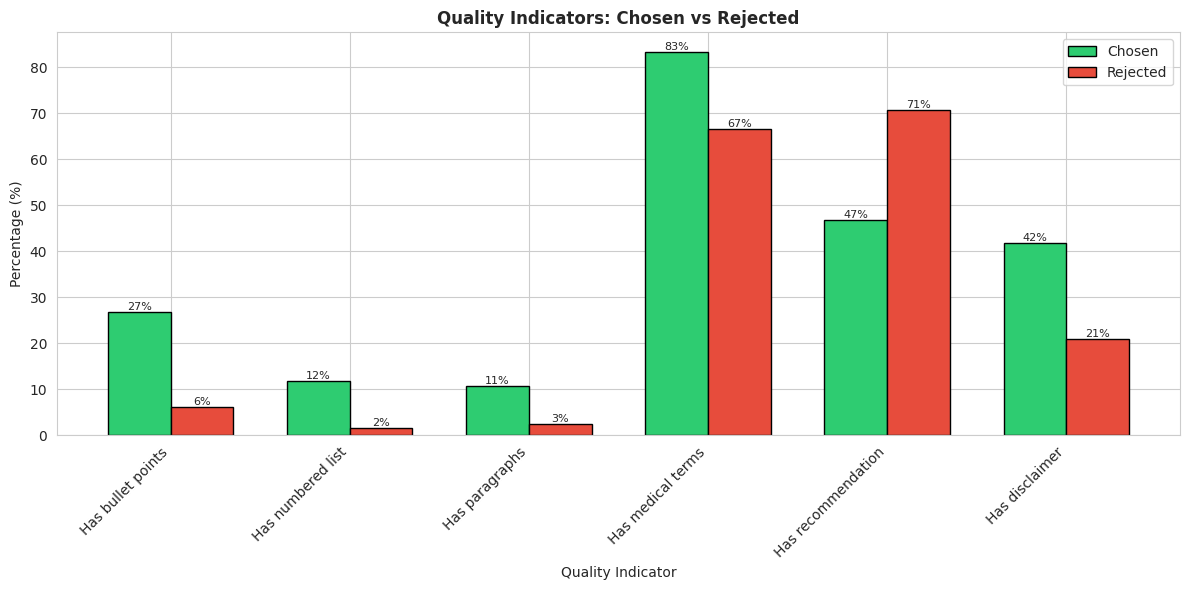

In [80]:
# Visualize quality comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(quality_comparison))
width = 0.35

bars1 = ax.bar(x - width/2, quality_comparison['Chosen (%)'], width, label='Chosen', color='#2ECC71', edgecolor='black')
bars2 = ax.bar(x + width/2, quality_comparison['Rejected (%)'], width, label='Rejected', color='#E74C3C', edgecolor='black')

ax.set_xlabel('Quality Indicator')
ax.set_ylabel('Percentage (%)')
ax.set_title('Quality Indicators: Chosen vs Rejected', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(quality_comparison['Quality Indicator'], rotation=45, ha='right')
ax.legend()

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}%',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}%',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## 8. Sample Data Inspection

### Kiểm tra mẫu data:
- Xem các cặp chosen/rejected điển hình
- Phát hiện patterns và potential issues
- Verify preference quality

In [60]:
def display_sample(row: pd.Series, idx: int):
    """Display a DPO sample in readable format."""
    print(f"\n{'='*80}")
    print(f"Sample #{idx}")
    print(f"{'='*80}")
    print(f"\n📝 PROMPT ({len(row['prompt'])} chars):")
    print(f"   {row['prompt'][:200]}{'...' if len(row['prompt']) > 200 else ''}")
    print(f"\n✅ CHOSEN ({len(row['chosen'])} chars):")
    print(f"   {row['chosen'][:300]}{'...' if len(row['chosen']) > 300 else ''}")
    print(f"\n❌ REJECTED ({len(row['rejected'])} chars):")
    print(f"   {row['rejected'][:300]}{'...' if len(row['rejected']) > 300 else ''}")
    print(f"\n📊 Similarity: {row['similarity']:.2f}")
    print(f"📏 Length diff: {row['len_diff']:+d} chars")

# Random samples
print("🔍 Random Samples from Dataset:")
sample_indices = np.random.choice(len(df), min(3, len(df)), replace=False)
for idx in sample_indices:
    display_sample(df.iloc[idx], idx)

🔍 Random Samples from Dataset:

Sample #3583

📝 PROMPT (133 chars):
   Tôi thấy trên mạng có chia sẻ về việc dùng áp lực cơ học lên vùng cổ để ‘kích hoạt tuần hoàn não’. Có thể tự thực hiện tại nhà không?

✅ CHOSEN (238 chars):
   Tác động cơ học lên vùng cổ có thể gây chèn ép mạch máu, tổn thương dây thần kinh hoặc ngất. Đây là hành động nguy hiểm và tuyệt đối không nên thử tại nhà. Nếu bạn gặp vấn đề về tuần hoàn hoặc đau đầu, hãy đến cơ sở y tế để được kiểm tra.

❌ REJECTED (209 chars):
   Một số bài viết phi chính thống nói rằng tác động nhẹ lên vùng cổ có thể cải thiện tuần hoàn não. Nếu làm đúng cách và với lực rất nhẹ, đa số sẽ không gây nguy hiểm, nhưng bạn nên ngừng ngay nếu thấy khó chịu.

📊 Similarity: 0.22
📏 Length diff: +29 chars

Sample #1683

📝 PROMPT (29 chars):
   Cao prolin tuýp 2 là bệnh gì?

✅ CHOSEN (514 chars):
   Cao prolin tuýp 2 (Hyperprolinemia Type II) là một rối loạn chuyển hóa di truyền hiếm gặp. Bệnh xảy ra do cơ thể thiếu hụt enzyme delta-pyrroline-5-carb

In [61]:
# Extreme cases
print("\n" + "="*80)
print("⚠️ EXTREME CASES")
print("="*80)

# Most similar
most_similar_idx = df['similarity'].idxmax()
print(f"\n🔄 Most Similar Pair (similarity = {df.loc[most_similar_idx, 'similarity']:.3f}):")
display_sample(df.loc[most_similar_idx], most_similar_idx)

# Biggest length difference
biggest_diff_idx = df['len_diff'].abs().idxmax()
print(f"\n📏 Biggest Length Difference ({df.loc[biggest_diff_idx, 'len_diff']:+d} chars):")
display_sample(df.loc[biggest_diff_idx], biggest_diff_idx)


⚠️ EXTREME CASES

🔄 Most Similar Pair (similarity = 0.698):

Sample #2177

📝 PROMPT (71 chars):
   Nêu những ưu điểm của phẫu thuật nội soi cắt u phì đại tuyến tiền liệt?

✅ CHOSEN (222 chars):
   Phẫu thuật nội soi cắt u phì đại tuyến tiền liệt an toàn, ít đau, không để lại sẹo, thời gian phục hồi nhanh và rút ngắn thời gian nằm viện. Giải thích chi tiết giúp người bệnh hiểu lợi ích và lựa chọn phương pháp phù hợp.

❌ REJECTED (145 chars):
   Phẫu thuật nội soi cắt u phì đại tuyến tiền liệt an toàn, ít đau, phục hồi nhanh. Không giải thích chi tiết hay so sánh với các phương pháp khác.

📊 Similarity: 0.70
📏 Length diff: +77 chars

📏 Biggest Length Difference (+1497 chars):

Sample #2923

📝 PROMPT (52 chars):
   Cách thực hiện test kích thích phế quản như thế nào?

✅ CHOSEN (2088 chars):
   Thực hiện test kích thích phế quản cần tuân thủ một quy trình **chính xác y tế** và chặt chẽ, được chia thành ba giai đoạn chính để đảm bảo **an toàn** và tính tin cậy của kết quả:

### 1. Chuẩn bị

---
## 9. Potential Issues Detection

### Kiểm tra các vấn đề tiềm ẩn:
- Duplicate prompts
- Very short responses
- Formatting issues
- Quality concerns

In [62]:
# Issue detection
issues = {
    'duplicate_prompts': df['prompt'].duplicated().sum(),
    'very_short_chosen': (df['chosen_len'] < 50).sum(),
    'very_short_rejected': (df['rejected_len'] < 30).sum(),
    'very_long_chosen': (df['chosen_len'] > 5000).sum(),
    'very_similar_pairs': (df['similarity'] > 0.9).sum(),
    'chosen_shorter_than_rejected': (df['len_diff'] < -200).sum(),
    'contains_urls_chosen': df['chosen'].str.contains(r'https?://', regex=True).sum(),
    'contains_urls_rejected': df['rejected'].str.contains(r'https?://', regex=True).sum(),
}

print("🔍 Potential Issues Detected:")
print("-" * 50)
for issue, count in issues.items():
    status = "⚠️" if count > len(df) * 0.01 else "✅"
    pct = 100 * count / len(df)
    print(f"   {status} {issue.replace('_', ' ').title()}: {count} ({pct:.2f}%)")

total_issues = sum(issues.values())
print(f"\n📊 Total issues flagged: {total_issues}")

🔍 Potential Issues Detected:
--------------------------------------------------
   ⚠️ Duplicate Prompts: 91 (2.44%)
   ✅ Very Short Chosen: 0 (0.00%)
   ✅ Very Short Rejected: 0 (0.00%)
   ✅ Very Long Chosen: 0 (0.00%)
   ✅ Very Similar Pairs: 0 (0.00%)
   ⚠️ Chosen Shorter Than Rejected: 102 (2.74%)
   ✅ Contains Urls Chosen: 0 (0.00%)
   ✅ Contains Urls Rejected: 0 (0.00%)

📊 Total issues flagged: 193


In [63]:
# Show samples of problematic entries
if issues['very_similar_pairs'] > 0:
    print("\n⚠️ Sample of Very Similar Pairs (similarity > 0.9):")
    similar_samples = df[df['similarity'] > 0.9].head(2)
    for idx, row in similar_samples.iterrows():
        print(f"\n--- Sample {idx} (similarity: {row['similarity']:.3f}) ---")
        print(f"Prompt: {row['prompt'][:100]}...")
        print(f"Chosen: {row['chosen'][:150]}...")
        print(f"Rejected: {row['rejected'][:150]}...")

if issues['duplicate_prompts'] > 0:
    print(f"\n⚠️ Duplicate prompts: {issues['duplicate_prompts']}")
    dup_prompts = df[df['prompt'].duplicated(keep=False)]['prompt'].value_counts().head(5)
    print("Top duplicated prompts:")
    for prompt, count in dup_prompts.items():
        print(f"   [{count}x] {prompt[:80]}...")


⚠️ Duplicate prompts: 91
Top duplicated prompts:
   [3x] Các triệu chứng của bệnh viêm đám rối thần kinh cánh tay là gì?...
   [3x] Trà Kombucha là gì?...
   [3x] Nội soi phế quản là gì?...
   [3x] Viêm sụn vành tai là gì?...
   [3x] Những đốm trắng trên bề mặt amidan là gì?...


---
## 10. Preprocessing Recommendations

### Dựa trên EDA, các bước preprocessing cho DPO data:

In [64]:
def preprocess_dpo_data(data: list[dict], config: dict = None) -> tuple[list[dict], dict]:
    """
    Preprocess DPO data based on EDA findings.
    
    Args:
        data: Raw DPO data
        config: Preprocessing configuration
        
    Returns:
        Cleaned data and statistics
    """
    if config is None:
        config = {
            'min_response_length': 30,
            'max_response_length': 6000,
            'min_similarity': 0.0,     # Remove if similarity = 0 (completely different)
            'max_similarity': 0.95,    # Remove if too similar
            'remove_duplicates': True,
            'normalize_whitespace': True
        }
    
    cleaned_data = []
    seen_prompts = set()
    
    stats = {
        'total': len(data),
        'removed_short': 0,
        'removed_long': 0,
        'removed_similar': 0,
        'removed_duplicate': 0
    }
    
    for entry in data:
        prompt = entry['prompt'].strip()
        chosen = entry['chosen'].strip()
        rejected = entry['rejected'].strip()
        
        # Normalize whitespace
        if config['normalize_whitespace']:
            prompt = ' '.join(prompt.split())
            chosen = ' '.join(chosen.split())
            rejected = ' '.join(rejected.split())
        
        # Length checks
        if len(chosen) < config['min_response_length'] or len(rejected) < config['min_response_length']:
            stats['removed_short'] += 1
            continue
        
        if len(chosen) > config['max_response_length'] or len(rejected) > config['max_response_length']:
            stats['removed_long'] += 1
            continue
        
        # Similarity check
        similarity = calculate_similarity(chosen, rejected)
        if similarity > config['max_similarity'] or similarity < config['min_similarity']:
            stats['removed_similar'] += 1
            continue
        
        # Duplicate prompt check
        if config['remove_duplicates']:
            prompt_hash = hash(prompt)
            if prompt_hash in seen_prompts:
                stats['removed_duplicate'] += 1
                continue
            seen_prompts.add(prompt_hash)
        
        cleaned_data.append({
            'prompt': prompt,
            'chosen': chosen,
            'rejected': rejected
        })
    
    stats['kept'] = len(cleaned_data)
    
    return cleaned_data, stats

# Run preprocessing (dry run)
cleaned_dpo, preprocess_stats = preprocess_dpo_data(dpo_data)

print("🧹 Preprocessing Results:")
print(f"   Original: {preprocess_stats['total']:,}")
print(f"   Kept: {preprocess_stats['kept']:,} ({100*preprocess_stats['kept']/preprocess_stats['total']:.1f}%)")
print(f"   Removed (short): {preprocess_stats['removed_short']}")
print(f"   Removed (long): {preprocess_stats['removed_long']}")
print(f"   Removed (similar): {preprocess_stats['removed_similar']}")
print(f"   Removed (duplicate): {preprocess_stats['removed_duplicate']}")

🧹 Preprocessing Results:
   Original: 3,722
   Kept: 3,631 (97.6%)
   Removed (short): 0
   Removed (long): 0
   Removed (similar): 0
   Removed (duplicate): 91


---
## 9.1 Extract Samples for Manual Review

### Thay vì remove các samples có vấn đề, extract ra file riêng để manual review:
- **Too long responses**: Cần rút gọn
- **Too short responses**: Cần bổ sung
- **Very similar pairs**: Preference signal yếu, cần review
- **Duplicates**: Cần quyết định giữ/xóa

### Workflow:
1. Extract samples có vấn đề → `tmp/dpo_manual_review/`
2. Sửa manual các samples
3. Merge lại về file data gốc

In [65]:
# Configuration for manual review extraction
DPO_REVIEW_CONFIG = {
    'max_response_length': 5000,   # Responses longer than this need review
    'min_response_length': 30,     # Responses shorter than this need review
    'max_similarity': 0.9,         # Very similar pairs need review
    'extract_duplicates': True,    # Also extract duplicate prompts
}

# Output directory
DPO_REVIEW_DIR = Path("../tmp/dpo_manual_review")
DPO_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

def extract_dpo_samples_for_review(df: pd.DataFrame, config: dict) -> dict:
    """
    Extract DPO samples that need manual review.
    
    Returns:
        Dictionary with categorized samples and their line numbers
    """
    review_samples = {
        'too_long': [],           # (line_number, entry)
        'too_short': [],          # (line_number, entry)
        'very_similar': [],       # (line_number, entry)
        'duplicate_prompts': [],  # (line_number, entry)
    }
    
    # Track seen prompts for duplicate detection
    seen_prompts = {}  # prompt -> first occurrence line
    
    for idx, row in df.iterrows():
        line_num = idx + 1  # 1-indexed
        entry = {
            'prompt': row['prompt'],
            'chosen': row['chosen'],
            'rejected': row['rejected']
        }
        
        # Check for too long responses
        if row['chosen_len'] > config['max_response_length'] or row['rejected_len'] > config['max_response_length']:
            review_samples['too_long'].append({
                'line': line_num,
                'chosen_len': row['chosen_len'],
                'rejected_len': row['rejected_len'],
                'entry': entry
            })
            continue  # Don't check other issues if already flagged
        
        # Check for too short responses
        if row['chosen_len'] < config['min_response_length'] or row['rejected_len'] < config['min_response_length']:
            review_samples['too_short'].append({
                'line': line_num,
                'chosen_len': row['chosen_len'],
                'rejected_len': row['rejected_len'],
                'entry': entry
            })
            continue
        
        # Check for very similar pairs
        if 'similarity' in row and row['similarity'] > config['max_similarity']:
            review_samples['very_similar'].append({
                'line': line_num,
                'similarity': row['similarity'],
                'entry': entry
            })
            continue
        
        # Check for duplicate prompts
        if config['extract_duplicates']:
            prompt_hash = hash(row['prompt'])
            if prompt_hash in seen_prompts:
                review_samples['duplicate_prompts'].append({
                    'line': line_num,
                    'duplicate_of_line': seen_prompts[prompt_hash],
                    'entry': entry
                })
            else:
                seen_prompts[prompt_hash] = line_num
    
    return review_samples

# Extract samples for review
dpo_review_samples = extract_dpo_samples_for_review(df, DPO_REVIEW_CONFIG)

print("🔍 DPO Samples Extracted for Manual Review:")
print(f"   📏 Too long (>{DPO_REVIEW_CONFIG['max_response_length']} chars): {len(dpo_review_samples['too_long'])}")
print(f"   📏 Too short (<{DPO_REVIEW_CONFIG['min_response_length']} chars): {len(dpo_review_samples['too_short'])}")
print(f"   🔄 Very similar (>{DPO_REVIEW_CONFIG['max_similarity']}): {len(dpo_review_samples['very_similar'])}")
print(f"   📋 Duplicate prompts: {len(dpo_review_samples['duplicate_prompts'])}")

🔍 DPO Samples Extracted for Manual Review:
   📏 Too long (>5000 chars): 0
   📏 Too short (<30 chars): 0
   🔄 Very similar (>0.9): 0
   📋 Duplicate prompts: 91


In [66]:
# Print detailed info about DPO samples needing review
def print_dpo_review_details(review_samples: dict):
    """Print detailed information about DPO samples needing manual review."""
    
    # Too Long Samples
    if review_samples['too_long']:
        print("\n" + "="*90)
        print("📏 TOO LONG RESPONSES - Need to shorten")
        print("="*90)
        print(f"{'Line':<8} {'Chosen Len':<12} {'Rejected Len':<12} {'Prompt Preview'}")
        print("-"*90)
        for item in review_samples['too_long']:
            prompt_preview = item['entry']['prompt'][:50].replace('\n', ' ') + "..."
            print(f"{item['line']:<8} {item['chosen_len']:<12} {item['rejected_len']:<12} {prompt_preview}")
    
    # Too Short Samples
    if review_samples['too_short']:
        print("\n" + "="*90)
        print("📏 TOO SHORT RESPONSES - Need to expand")
        print("="*90)
        print(f"{'Line':<8} {'Chosen Len':<12} {'Rejected Len':<12} {'Prompt Preview'}")
        print("-"*90)
        for item in review_samples['too_short'][:20]:
            prompt_preview = item['entry']['prompt'][:50].replace('\n', ' ') + "..."
            print(f"{item['line']:<8} {item['chosen_len']:<12} {item['rejected_len']:<12} {prompt_preview}")
        if len(review_samples['too_short']) > 20:
            print(f"... and {len(review_samples['too_short']) - 20} more")
    
    # Very Similar Pairs
    if review_samples['very_similar']:
        print("\n" + "="*90)
        print("🔄 VERY SIMILAR PAIRS - Weak preference signal, need differentiation")
        print("="*90)
        print(f"{'Line':<8} {'Similarity':<12} {'Prompt Preview'}")
        print("-"*90)
        for item in review_samples['very_similar'][:20]:
            prompt_preview = item['entry']['prompt'][:60].replace('\n', ' ') + "..."
            print(f"{item['line']:<8} {item['similarity']:<12.3f} {prompt_preview}")
        if len(review_samples['very_similar']) > 20:
            print(f"... and {len(review_samples['very_similar']) - 20} more")
    
    # Duplicate Prompts
    if review_samples['duplicate_prompts']:
        print("\n" + "="*90)
        print("📋 DUPLICATE PROMPTS - Need to merge or remove")
        print("="*90)
        print(f"{'Line':<8} {'Duplicate of':<15} {'Prompt Preview'}")
        print("-"*90)
        for item in review_samples['duplicate_prompts'][:20]:
            prompt_preview = item['entry']['prompt'][:55].replace('\n', ' ') + "..."
            print(f"{item['line']:<8} Line {item['duplicate_of_line']:<10} {prompt_preview}")
        if len(review_samples['duplicate_prompts']) > 20:
            print(f"... and {len(review_samples['duplicate_prompts']) - 20} more")

# Print details
print_dpo_review_details(dpo_review_samples)


📋 DUPLICATE PROMPTS - Need to merge or remove
Line     Duplicate of    Prompt Preview
------------------------------------------------------------------------------------------
177      Line 153        Ruột thừa là gì và chức năng của nó là gì?...
186      Line 162        Chỉ số HGB trong xét nghiệm máu là gì?...
219      Line 66         Liên cầu khuẩn lợn là gì?...
387      Line 295        Triệu chứng sốt xuất huyết Dengue thường xuất hiện sau ...
390      Line 297        Bệnh nhược cơ là gì?...
391      Line 298        Biến chứng nguy hiểm của bệnh nhược cơ là gì?...
406      Line 314        Điều trị phì đại tuyến tiền liệt như thế nào?...
477      Line 324        Viêm mũi xoang là gì?...
492      Line 339        Thoát vị đĩa đệm là gì và nguyên nhân dẫn đến bệnh này?...
494      Line 341        Khi nào nên chụp X quang thoát vị đĩa đệm?...
513      Line 354        Vì sao cần dùng chụp cộng hưởng từ trong chẩn đoán sớm ...
515      Line 356        Khi nào không thể chụp cộng hưởng t

In [67]:
# Export DPO samples to separate files for manual review
def export_dpo_for_manual_review(review_samples: dict, output_dir: Path, original_file: Path):
    """
    Export DPO samples needing review to separate JSONL files.
    
    Files created:
    - dpo_too_long.jsonl: Samples with too long responses
    - dpo_too_short.jsonl: Samples with too short responses
    - dpo_very_similar.jsonl: Very similar chosen/rejected pairs
    - dpo_duplicates.jsonl: Duplicate prompt samples
    - dpo_lines_to_review.txt: List of line numbers
    """
    
    lines_to_review = set()
    
    # Export too long samples
    if review_samples['too_long']:
        filepath = output_dir / "dpo_too_long.jsonl"
        with open(filepath, 'w', encoding='utf-8') as f:
            for item in review_samples['too_long']:
                lines_to_review.add(item['line'])
                output = {
                    '_metadata': {
                        'original_line': item['line'],
                        'issue': 'too_long',
                        'chosen_len': item['chosen_len'],
                        'rejected_len': item['rejected_len']
                    },
                    **item['entry']
                }
                f.write(json.dumps(output, ensure_ascii=False) + '\n')
        print(f"✅ Exported {len(review_samples['too_long'])} too-long samples to {filepath}")
    
    # Export too short samples
    if review_samples['too_short']:
        filepath = output_dir / "dpo_too_short.jsonl"
        with open(filepath, 'w', encoding='utf-8') as f:
            for item in review_samples['too_short']:
                lines_to_review.add(item['line'])
                output = {
                    '_metadata': {
                        'original_line': item['line'],
                        'issue': 'too_short',
                        'chosen_len': item['chosen_len'],
                        'rejected_len': item['rejected_len']
                    },
                    **item['entry']
                }
                f.write(json.dumps(output, ensure_ascii=False) + '\n')
        print(f"✅ Exported {len(review_samples['too_short'])} too-short samples to {filepath}")
    
    # Export very similar samples
    if review_samples['very_similar']:
        filepath = output_dir / "dpo_very_similar.jsonl"
        with open(filepath, 'w', encoding='utf-8') as f:
            for item in review_samples['very_similar']:
                lines_to_review.add(item['line'])
                output = {
                    '_metadata': {
                        'original_line': item['line'],
                        'issue': 'very_similar',
                        'similarity': item['similarity']
                    },
                    **item['entry']
                }
                f.write(json.dumps(output, ensure_ascii=False) + '\n')
        print(f"✅ Exported {len(review_samples['very_similar'])} very-similar samples to {filepath}")
    
    # Export duplicates
    if review_samples['duplicate_prompts']:
        filepath = output_dir / "dpo_duplicates.jsonl"
        with open(filepath, 'w', encoding='utf-8') as f:
            for item in review_samples['duplicate_prompts']:
                lines_to_review.add(item['line'])
                output = {
                    '_metadata': {
                        'original_line': item['line'],
                        'issue': 'duplicate',
                        'duplicate_of_line': item['duplicate_of_line']
                    },
                    **item['entry']
                }
                f.write(json.dumps(output, ensure_ascii=False) + '\n')
        print(f"✅ Exported {len(review_samples['duplicate_prompts'])} duplicate samples to {filepath}")
    
    # Export line numbers
    lines_file = output_dir / "dpo_lines_to_review.txt"
    with open(lines_file, 'w') as f:
        f.write("# Line numbers in original file that need manual review\n")
        f.write(f"# Original file: {original_file}\n")
        f.write(f"# Total lines to review: {len(lines_to_review)}\n\n")
        for line in sorted(lines_to_review):
            f.write(f"{line}\n")
    print(f"✅ Line numbers saved to {lines_file}")
    
    # Create clean version
    clean_filepath = output_dir / "dpo_clean.jsonl"
    with open(original_file, 'r', encoding='utf-8') as f_in:
        with open(clean_filepath, 'w', encoding='utf-8') as f_out:
            for idx, line in enumerate(f_in, 1):
                if idx not in lines_to_review:
                    f_out.write(line)
    
    clean_count = len(dpo_data) - len(lines_to_review)
    print(f"✅ Clean data ({clean_count} samples) saved to {clean_filepath}")
    
    return lines_to_review

# Export files
print("\n📤 Exporting DPO samples for manual review...")
print(f"📁 Output directory: {DPO_REVIEW_DIR.absolute()}\n")

dpo_lines_to_review = export_dpo_for_manual_review(
    dpo_review_samples,
    DPO_REVIEW_DIR,
    DATA_PATH
)

print(f"\n📊 Summary:")
print(f"   Total samples needing review: {len(dpo_lines_to_review)}")
print(f"   Clean samples: {len(dpo_data) - len(dpo_lines_to_review)}")


📤 Exporting DPO samples for manual review...
📁 Output directory: /home/minhquana/workspace/project_LargeLanguageModel/ViMed-Assistant-With-Preference-Alignment/notebooks/../tmp/dpo_manual_review

✅ Exported 91 duplicate samples to ../tmp/dpo_manual_review/dpo_duplicates.jsonl
✅ Line numbers saved to ../tmp/dpo_manual_review/dpo_lines_to_review.txt
✅ Clean data (3631 samples) saved to ../tmp/dpo_manual_review/dpo_clean.jsonl

📊 Summary:
   Total samples needing review: 91
   Clean samples: 3631


### 📝 DPO Manual Review Workflow

Sau khi export, thực hiện các bước sau:

1. **Review các file trong `tmp/dpo_manual_review/`:**
   - `dpo_too_long.jsonl` - Rút gọn responses quá dài
   - `dpo_too_short.jsonl` - Bổ sung thêm nội dung
   - `dpo_very_similar.jsonl` - Làm rõ sự khác biệt chosen/rejected
   - `dpo_duplicates.jsonl` - Quyết định giữ/xóa

2. **Khi sửa:**
   - Remove trường `_metadata` sau khi sửa xong
   - Đảm bảo `chosen` và `rejected` có sự khác biệt rõ ràng

3. **Merge lại vào file gốc:**

In [81]:
# Function to merge reviewed DPO samples back to original file
def merge_dpo_reviewed_samples(
    original_file: Path,
    review_dir: Path,
    output_file: Path,
    remove_duplicates: bool = True
):
    """
    Merge manually reviewed DPO samples back into the dataset.
    """
    reviewed = {}  # line_number -> entry
    files_to_check = [
        'dpo_too_long.jsonl',
        'dpo_too_short.jsonl',
        'dpo_very_similar.jsonl',
    ]
    
    # Load reviewed files
    for filename in files_to_check:
        filepath = review_dir / filename
        if filepath.exists():
            count = 0
            with open(filepath, 'r', encoding='utf-8') as f:
                for line in f:
                    entry = json.loads(line.strip())
                    if '_metadata' in entry:
                        line_num = entry['_metadata']['original_line']
                        del entry['_metadata']
                        reviewed[line_num] = entry
                        count += 1
            if count > 0:
                print(f"📖 Loaded {count} entries from {filename}")
    
    # Get duplicate line numbers to remove
    duplicates_to_remove = set()
    if remove_duplicates:
        dup_file = review_dir / 'dpo_duplicates.jsonl'
        if dup_file.exists():
            with open(dup_file, 'r', encoding='utf-8') as f:
                for line in f:
                    entry = json.loads(line.strip())
                    if '_metadata' in entry:
                        duplicates_to_remove.add(entry['_metadata']['original_line'])
            print(f"🔄 Found {len(duplicates_to_remove)} duplicates to remove")
    
    # Merge
    merged_count = 0
    removed_count = 0
    
    with open(original_file, 'r', encoding='utf-8') as f_in:
        with open(output_file, 'w', encoding='utf-8') as f_out:
            for idx, line in enumerate(f_in, 1):
                if idx in duplicates_to_remove:
                    removed_count += 1
                    continue
                
                if idx in reviewed:
                    f_out.write(json.dumps(reviewed[idx], ensure_ascii=False) + '\n')
                    merged_count += 1
                else:
                    f_out.write(line)
    
    print(f"\n✅ Merge complete!")
    print(f"   Merged reviewed entries: {merged_count}")
    print(f"   Removed duplicates: {removed_count}")
    print(f"   Output file: {output_file}")

# Uncomment and run after manual review is complete
merge_dpo_reviewed_samples(
    original_file=DATA_PATH,
    review_dir=DPO_REVIEW_DIR,
    output_file=Path("../data/final_dpo_reviewed.jsonl"),
    remove_duplicates=True
)

🔄 Found 91 duplicates to remove

✅ Merge complete!
   Merged reviewed entries: 0
   Removed duplicates: 91
   Output file: ../data/final_dpo_reviewed.jsonl


---
## 11. Export Cleaned Data (Optional)

In [82]:
def export_dpo_data(data: list[dict], output_path: Path):
    """
    Export cleaned DPO data to JSONL file.
    """
    with open(output_path, 'w', encoding='utf-8') as f:
        for entry in data:
            f.write(json.dumps(entry, ensure_ascii=False) + '\n')
    print(f"✅ Exported {len(data):,} entries to {output_path}")

# Uncomment to export
OUTPUT_PATH = Path("../data/final_dpo_cleaned.jsonl")
export_dpo_data(cleaned_dpo, OUTPUT_PATH)

✅ Exported 3,631 entries to ../data/final_dpo_cleaned.jsonl


---
## 📋 Summary & Recommendations

### Key Findings:
1. **Length Analysis**: Phân bố độ dài và potential length bias
2. **Similarity Analysis**: Sự khác biệt giữa chosen và rejected
3. **Quality Indicators**: Đặc điểm chất lượng của responses
4. **Issues Detected**: Các vấn đề cần xử lý

### DPO Training Recommendations:
- **max_length**: Dựa trên 99th percentile của total tokens
- **beta**: Nếu similarity cao, có thể cần tăng beta
- **Learning rate**: Thường nhỏ hơn SFT (1e-6 to 5e-7)
- **Epochs**: 1-3 epochs thường đủ cho DPO

### Preprocessing Checklist:
- [ ] Remove duplicate prompts
- [ ] Filter very similar chosen/rejected pairs
- [ ] Balance length distribution if needed
- [ ] Verify preference quality on sample

In [70]:
# Final summary
print("="*60)
print("📊 DPO DATASET EDA SUMMARY")
print("="*60)
print(f"\n📁 Dataset: {DATA_PATH}")
print(f"📝 Total samples: {len(df):,}")
print(f"📏 Avg prompt length: {df['prompt_len'].mean():.0f} chars")
print(f"📏 Avg chosen length: {df['chosen_len'].mean():.0f} chars")
print(f"📏 Avg rejected length: {df['rejected_len'].mean():.0f} chars")
print(f"🔄 Avg similarity: {df['similarity'].mean():.2f}")
print(f"📊 Length bias: Chosen longer in {100*(df['len_diff'] > 0).mean():.1f}% cases")

if HAS_TOKEN_DATA:
    print(f"🔢 Avg total tokens: {df['total_tokens'].mean():.0f}")
    print(f"🔢 Recommended max_length: {int(np.percentile(df['total_tokens'], 99))}")

print(f"\n✅ Ready for DPO training!")
print("="*60)

📊 DPO DATASET EDA SUMMARY

📁 Dataset: ../data/dpo.jsonl
📝 Total samples: 3,722
📏 Avg prompt length: 70 chars
📏 Avg chosen length: 379 chars
📏 Avg rejected length: 253 chars
🔄 Avg similarity: 0.23
📊 Length bias: Chosen longer in 88.1% cases
🔢 Avg total tokens: 136
🔢 Recommended max_length: 349

✅ Ready for DPO training!
